In [1]:
# =========================================
# RHC-UCRL style CartPole - STABLE VERSION
# Fixed adversarial perturbation, stable learning
# =========================================

import copy
import random
from collections import deque

import gymnasium as gym
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Reproducibility
# -----------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# =========================================
# Replay Buffer with Prioritized Experience
# =========================================
class PrioritizedBuffer:
    def __init__(self, size=100000, alpha=0.6, beta=0.4):
        self.buffer = deque(maxlen=size)
        self.priorities = deque(maxlen=size)
        self.alpha = alpha  # how much to use priorities
        self.beta = beta    # importance sampling correction
        self.max_priority = 1.0
        
    def add(self, s, a, adv, r, c, s_next, done, priority=None):
        self.buffer.append((s, a, adv, r, c, s_next, done))
        if priority is None:
            priority = self.max_priority
        self.priorities.append(priority)
        
    def sample(self, batch_size):
        # Convert to numpy for sampling
        priorities = np.array(self.priorities)
        probs = priorities ** self.alpha
        probs /= probs.sum()
        
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        
        # Importance sampling weights
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-self.beta)
        weights /= weights.max()
        weights = torch.tensor(weights, dtype=torch.float32, device=device).unsqueeze(1)
        
        batch = [self.buffer[i] for i in indices]
        s, a, adv, r, c, s_next, done = zip(*batch)
        
        return (
            torch.tensor(np.array(s), dtype=torch.float32, device=device),
            torch.tensor(np.array(a), dtype=torch.long, device=device).unsqueeze(1),
            torch.tensor(np.array(adv), dtype=torch.float32, device=device),
            torch.tensor(np.array(r), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(c), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32, device=device),
            torch.tensor(np.array(done), dtype=torch.float32, device=device).unsqueeze(1),
            weights,
            indices
        )
    
    def update_priorities(self, indices, priorities):
        for idx, priority in zip(indices, priorities):
            self.priorities[idx] = priority
            self.max_priority = max(self.max_priority, priority)
    
    def __len__(self):
        return len(self.buffer)

# =========================================
# Helper functions
# =========================================
def one_hot_actions(a_idx, a_dim):
    return F.one_hot(a_idx.squeeze(1), num_classes=a_dim).float()

def soft_update(net, target_net, tau):
    for p, tp in zip(net.parameters(), target_net.parameters()):
        tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)

def gradient_penalty(critic, s, a_onehot, adv):
    """Gradient penalty for Lipschitz constraint"""
    s.requires_grad_(True)
    a_onehot.requires_grad_(True)
    adv.requires_grad_(True)
    
    q = critic(s, a_onehot, adv)
    gradients = torch.autograd.grad(
        outputs=q,
        inputs=[s, a_onehot, adv],
        grad_outputs=torch.ones_like(q),
        create_graph=True,
        retain_graph=True
    )
    
    penalty = 0
    for grad in gradients:
        if grad is not None:
            penalty += ((grad.norm(2, dim=1) - 1).clamp(min=0) ** 2).mean()
    
    return penalty

# =========================================
# Networks
# =========================================
class Actor(nn.Module):
    def __init__(self, s_dim, a_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, a_dim)
        )
        
    def forward(self, s):
        logits = self.net(s)
        probs = F.softmax(logits, dim=-1)
        return probs

class Adversary(nn.Module):
    def __init__(self, s_dim, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, adv_dim),
            nn.Tanh()
        )
        
    def forward(self, s):
        return self.net(s)

class Critic(nn.Module):
    def __init__(self, s_dim, a_dim, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim + a_dim + adv_dim, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, 1)
        )
        
    def forward(self, s, a_onehot, adv):
        x = torch.cat([s, a_onehot, adv], dim=-1)
        return self.net(x)

# =========================================
# Dynamics ensemble with better uncertainty
# =========================================
class DynamicsModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim)
        )
        
    def forward(self, x):
        return self.net(x)

class Ensemble:
    def __init__(self, in_dim, hidden_dim, out_dim, K=7, lr=1e-3):
        self.models = [DynamicsModel(in_dim, hidden_dim, out_dim).to(device) for _ in range(K)]
        self.opts = [torch.optim.Adam(m.parameters(), lr=lr) for m in self.models]
        self.K = K
        
    def predict(self, s, a_onehot, adv):
        x = torch.cat([s, a_onehot, adv], dim=-1)
        preds = torch.stack([m(x) for m in self.models], dim=0)
        mu = preds.mean(dim=0)
        sigma = preds.std(dim=0)
        return mu, sigma
    
    def predict_with_uncertainty(self, s, a_onehot, adv):
        """Return uncertainty as norm of standard deviation"""
        _, sigma = self.predict(s, a_onehot, adv)
        return sigma.norm(dim=1, keepdim=True)
    
    def train_step(self, S, A_onehot, ADV, S_next, weights=None):
        delta = S_next - S
        losses = []
        
        for model, opt in zip(self.models, self.opts):
            # Bootstrap sampling
            idx = torch.randint(0, S.shape[0], (max(64, S.shape[0] // 2),), device=device)
            
            s_i = S[idx]
            a_i = A_onehot[idx]
            adv_i = ADV[idx]
            delta_i = delta[idx]
            
            x = torch.cat([s_i, a_i, adv_i], dim=-1)
            pred = model(x)
            loss = F.mse_loss(pred, delta_i)
            
            if weights is not None:
                loss = (loss * weights[idx].squeeze()).mean()
            
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()
            
            losses.append(loss.item())
            
        return np.mean(losses)

# =========================================
# Fixed Adversarial CartPole Environment
# =========================================
class AdversarialCartPole:
    """
    Properly applies adversarial perturbation to OBSERVATIONS
    The adversary perturbs what the agent sees, not the dynamics
    """
    def __init__(self, adv_scale=None):
        self.env = gym.make("CartPole-v1")
        if adv_scale is None:
            adv_scale = np.array([0.02, 0.02, 0.01, 0.02], dtype=np.float32)
        self.adv_scale = adv_scale.astype(np.float32)
        self.current_true_state = None
        
    def reset(self):
        s, _ = self.env.reset()
        self.current_true_state = np.array(s, dtype=np.float32)
        # Initial observation is clean
        return self.current_true_state.copy()
    
    def step(self, action, adv_perturbation):
        """
        Args:
            action: action to take (0 or 1)
            adv_perturbation: perturbation to apply to observation
        """
        # Clip adversarial perturbation
        adv_perturbation = np.clip(adv_perturbation, -1.0, 1.0)
        pert = adv_perturbation * self.adv_scale
        
        # Apply perturbation to CURRENT observation
        # This is what the agent SEES
        perturbed_obs = self.current_true_state + pert
        
        # Take action in environment using true state
        next_true_state, reward, terminated, truncated, _ = self.env.step(int(action))
        next_true_state = np.array(next_true_state, dtype=np.float32)
        
        # Compute safety cost based on true state
        x, x_dot, theta, theta_dot = next_true_state
        cost = (
            2.0 * max(0.0, abs(theta) - 0.05) +
            0.5 * max(0.0, abs(x) - 1.5)
        )
        
        if terminated:
            cost += 5.0
        
        done = terminated or truncated
        self.current_true_state = next_true_state
        
        # Return perturbed observation (what agent sees) but true reward/cost
        return perturbed_obs, float(reward), float(cost), done

# =========================================
# Action selection with exploration
# =========================================
def select_action(actor, s_np, epsilon):
    s_t = torch.tensor(s_np, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        probs = actor(s_t).squeeze(0).cpu().numpy()
    
    if np.random.rand() < epsilon:
        action = np.random.randint(len(probs))
    else:
        action = int(np.argmax(probs))
    
    return action, probs

# =========================================
# Hyperparameters - Tuned for Stability
# =========================================
s_dim = 4
a_dim = 2
adv_dim = 4

# Training parameters
H = 500                        # rollout horizon
num_rollouts_per_update = 4    # collect multiple rollouts before update
outer_iters = 2000             # total iterations
batch_size = 256
warmup_steps = 10000           # steps before training
update_steps = 10              # critic updates per training phase

# RL parameters
gamma = 0.99
tau_soft = 0.005
lambda_ = torch.tensor(30.0, dtype=torch.float32, device=device)  # Cost penalty
b = 10.0                       # Cost threshold

# Bonus parameters
beta = 0.05                    # Reward uncertainty bonus
alpha = 0.05                   # Cost uncertainty bonus

# Learning rates
actor_lr = 1e-4                # Lower for stability
adv_lr = 1e-4
critic_lr = 3e-4
ensemble_lr = 1e-3

# Exploration
epsilon_start = 0.3
epsilon_end = 0.02             # Keep some exploration
epsilon_decay = 0.998

# Gradient penalty
gp_weight = 0.1

# =========================================
# Initialize components
# =========================================
env = AdversarialCartPole()
buffer = PrioritizedBuffer(size=200000)

actor = Actor(s_dim, a_dim).to(device)
adversary = Adversary(s_dim, adv_dim).to(device)

# Critics: optimistic and pessimistic for reward and cost
critic_r_o = Critic(s_dim, a_dim, adv_dim).to(device)
critic_r_p = Critic(s_dim, a_dim, adv_dim).to(device)
critic_c_o = Critic(s_dim, a_dim, adv_dim).to(device)
critic_c_p = Critic(s_dim, a_dim, adv_dim).to(device)

# Target networks
critic_r_o_target = copy.deepcopy(critic_r_o)
critic_r_p_target = copy.deepcopy(critic_r_p)
critic_c_o_target = copy.deepcopy(critic_c_o)
critic_c_p_target = copy.deepcopy(critic_c_p)

# Optimizers
opt_actor = torch.optim.Adam(actor.parameters(), lr=actor_lr)
opt_adv = torch.optim.Adam(adversary.parameters(), lr=adv_lr)
opt_r_o = torch.optim.Adam(critic_r_o.parameters(), lr=critic_lr)
opt_r_p = torch.optim.Adam(critic_r_p.parameters(), lr=critic_lr)
opt_c_o = torch.optim.Adam(critic_c_o.parameters(), lr=critic_lr)
opt_c_p = torch.optim.Adam(critic_c_p.parameters(), lr=critic_lr)

# Schedulers for stability
scheduler_actor = torch.optim.lr_scheduler.CosineAnnealingLR(opt_actor, T_max=outer_iters)
scheduler_adv = torch.optim.lr_scheduler.CosineAnnealingLR(opt_adv, T_max=outer_iters)

# Ensemble
ensemble = Ensemble(
    in_dim=s_dim + a_dim + adv_dim,
    hidden_dim=256,
    out_dim=s_dim,
    K=7,
    lr=ensemble_lr,
)

# =========================================
# Logging
# =========================================
reward_history = []
cost_history = []
actor_loss_history = []
adv_loss_history = []
critic_loss_history = []
uncertainty_history = []

print("Start stable training...")

# Warmup phase - collect initial data
print("Collecting warmup data...")
warmup_pbar = tqdm(range(warmup_steps), desc="Warmup")
for step in warmup_pbar:
    s = env.reset()
    for _ in range(H):
        a = np.random.randint(a_dim)
        adv_vec = np.random.uniform(-1, 1, adv_dim)
        s_next, r, c, done = env.step(a, adv_vec)
        buffer.add(s, a, adv_vec, r, c, s_next, done, priority=1.0)
        s = s_next
        if done:
            break
    warmup_pbar.set_postfix({"Buffer": len(buffer)})

print(f"Warmup complete. Buffer size: {len(buffer)}")

# =========================================
# Main training loop
# =========================================
for t in tqdm(range(outer_iters), desc="Training"):
    # ------------------------------------------------------
    # 1) Collect multiple rollouts
    # ------------------------------------------------------
    epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** t))
    total_reward_this_iter = 0
    total_cost_this_iter = 0
    
    for _ in range(num_rollouts_per_update):
        s = env.reset()
        episode_reward = 0
        episode_cost = 0
        
        for h in range(H):
            # Select action and adversary
            a, probs = select_action(actor, s, epsilon=epsilon)
            s_t = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            
            with torch.no_grad():
                adv_vec = adversary(s_t).squeeze(0).cpu().numpy()
                adv_vec = np.clip(adv_vec, -1.0, 1.0)
            
            # Step environment
            s_next, r, c, done = env.step(a, adv_vec)
            
            # Store transition with priority
            buffer.add(s, a, adv_vec, r, c, s_next, done, priority=1.0)
            
            s = s_next
            episode_reward += r
            episode_cost += c
            
            if done:
                break
        
        total_reward_this_iter += episode_reward
        total_cost_this_iter += episode_cost
    
    avg_reward = total_reward_this_iter / num_rollouts_per_update
    avg_cost = total_cost_this_iter / num_rollouts_per_update
    
    reward_history.append(avg_reward)
    cost_history.append(avg_cost)
    
    # ------------------------------------------------------
    # 2) Update models and critics
    # ------------------------------------------------------
    if len(buffer) >= warmup_steps:
        critic_losses = []
        ensemble_losses = []
        
        for update in range(update_steps):
            # Sample from buffer
            S, A_idx, ADV, R, C, S_next, D, weights, indices = buffer.sample(batch_size)
            A_onehot = one_hot_actions(A_idx, a_dim)
            
            # Train ensemble with importance weights
            ensemble_loss = ensemble.train_step(S, A_onehot, ADV, S_next, weights)
            ensemble_losses.append(ensemble_loss)
            
            with torch.no_grad():
                # Get next actions and adversary
                next_probs = actor(S_next)
                ADV_next = adversary(S_next)
                
                # Calculate action-dependent uncertainty
                uncertainty_per_action = []
                for action_id in range(a_dim):
                    a_tmp = torch.full((batch_size, 1), action_id, dtype=torch.long, device=device)
                    a_tmp_oh = one_hot_actions(a_tmp, a_dim)
                    unc = ensemble.predict_with_uncertainty(S_next, a_tmp_oh, ADV_next)
                    uncertainty_per_action.append(unc)
                
                # Weighted uncertainty by policy
                uncertainty = torch.zeros(batch_size, 1, device=device)
                for action_id in range(a_dim):
                    uncertainty += next_probs[:, action_id:action_id+1] * uncertainty_per_action[action_id]
                
                # Compute target Q values
                next_q_r_o = 0
                next_q_r_p = 0
                next_q_c_o = 0
                next_q_c_p = 0
                
                for action_id in range(a_dim):
                    a_tmp = torch.full((batch_size, 1), action_id, dtype=torch.long, device=device)
                    a_tmp_oh = one_hot_actions(a_tmp, a_dim)
                    p = next_probs[:, action_id:action_id+1]
                    
                    next_q_r_o += p * critic_r_o_target(S_next, a_tmp_oh, ADV_next)
                    next_q_r_p += p * critic_r_p_target(S_next, a_tmp_oh, ADV_next)
                    next_q_c_o += p * critic_c_o_target(S_next, a_tmp_oh, ADV_next)
                    next_q_c_p += p * critic_c_p_target(S_next, a_tmp_oh, ADV_next)
                
                not_done = 1.0 - D
                
                # Targets with uncertainty bonuses
                target_r_o = R + beta * uncertainty + gamma * not_done * next_q_r_o
                target_r_p = R - beta * uncertainty + gamma * not_done * next_q_r_p
                target_c_o = C + alpha * uncertainty + gamma * not_done * next_q_c_o
                target_c_p = C - alpha * uncertainty + gamma * not_done * next_q_c_p
            
            # Update critics with gradient penalty
            # Optimistic reward critic
            pred_r_o = critic_r_o(S, A_onehot, ADV)
            loss_r_o = F.mse_loss(pred_r_o, target_r_o, reduction='none')
            loss_r_o = (loss_r_o * weights).mean()
            loss_r_o += gp_weight * gradient_penalty(critic_r_o, S, A_onehot, ADV)
            
            # Pessimistic reward critic
            pred_r_p = critic_r_p(S, A_onehot, ADV)
            loss_r_p = F.mse_loss(pred_r_p, target_r_p, reduction='none')
            loss_r_p = (loss_r_p * weights).mean()
            loss_r_p += gp_weight * gradient_penalty(critic_r_p, S, A_onehot, ADV)
            
            # Optimistic cost critic
            pred_c_o = critic_c_o(S, A_onehot, ADV)
            loss_c_o = F.mse_loss(pred_c_o, target_c_o, reduction='none')
            loss_c_o = (loss_c_o * weights).mean()
            loss_c_o += gp_weight * gradient_penalty(critic_c_o, S, A_onehot, ADV)
            
            # Pessimistic cost critic
            pred_c_p = critic_c_p(S, A_onehot, ADV)
            loss_c_p = F.mse_loss(pred_c_p, target_c_p, reduction='none')
            loss_c_p = (loss_c_p * weights).mean()
            loss_c_p += gp_weight * gradient_penalty(critic_c_p, S, A_onehot, ADV)
            
            # Optimizer steps
            opt_r_o.zero_grad()
            loss_r_o.backward()
            torch.nn.utils.clip_grad_norm_(critic_r_o.parameters(), 0.5)
            opt_r_o.step()
            
            opt_r_p.zero_grad()
            loss_r_p.backward()
            torch.nn.utils.clip_grad_norm_(critic_r_p.parameters(), 0.5)
            opt_r_p.step()
            
            opt_c_o.zero_grad()
            loss_c_o.backward()
            torch.nn.utils.clip_grad_norm_(critic_c_o.parameters(), 0.5)
            opt_c_o.step()
            
            opt_c_p.zero_grad()
            loss_c_p.backward()
            torch.nn.utils.clip_grad_norm_(critic_c_p.parameters(), 0.5)
            opt_c_p.step()
            
            # Soft updates
            soft_update(critic_r_o, critic_r_o_target, tau_soft)
            soft_update(critic_r_p, critic_r_p_target, tau_soft)
            soft_update(critic_c_o, critic_c_o_target, tau_soft)
            soft_update(critic_c_p, critic_c_p_target, tau_soft)
            
            # Update priorities based on TD error
            with torch.no_grad():
                td_error = torch.abs(pred_r_o - target_r_o).squeeze().cpu().numpy()
                priorities = td_error + 1e-6
                buffer.update_priorities(indices, priorities)
            
            critic_losses.append((loss_r_o.item() + loss_r_p.item() + loss_c_o.item() + loss_c_p.item()) / 4)
        
        critic_loss_history.append(np.mean(critic_losses))
        uncertainty_history.append(uncertainty.mean().item())
        
        # ------------------------------------------------------
        # 3) Update actor (same batch for stability)
        # ------------------------------------------------------
        # Sample once for both actor and adversary
        S, A_idx, ADV, R, C, S_next, D, weights, indices = buffer.sample(batch_size)
        A_onehot = one_hot_actions(A_idx, a_dim)
        
        # Actor update
        probs_pred = actor(S)
        ADV_fixed = adversary(S).detach()
        
        exp_q_r = 0
        exp_q_c = 0
        
        for action_id in range(a_dim):
            a_tmp = torch.full((batch_size, 1), action_id, dtype=torch.long, device=device)
            a_tmp_oh = one_hot_actions(a_tmp, a_dim)
            p = probs_pred[:, action_id:action_id+1]
            
            exp_q_r += p * critic_r_o(S, a_tmp_oh, ADV_fixed)
            exp_q_c += p * critic_c_o(S, a_tmp_oh, ADV_fixed)
        
        # Entropy bonus for exploration
        entropy = -(probs_pred * torch.log(probs_pred + 1e-8)).sum(dim=1).mean()
        entropy_coef = max(0.01, 0.1 * (1 - t / outer_iters))  # Anneal entropy
        
        actor_loss = -(exp_q_r - lambda_ * torch.relu(exp_q_c - b)).mean() - entropy_coef * entropy
        
        opt_actor.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(actor.parameters(), 0.5)
        opt_actor.step()
        
        actor_loss_history.append(actor_loss.item())
        
        # ------------------------------------------------------
        # 4) Update adversary (same batch)
        # ------------------------------------------------------
        ADV_pred = adversary(S)
        probs_fixed = actor(S).detach()
        
        adv_obj = 0
        for action_id in range(a_dim):
            a_tmp = torch.full((batch_size, 1), action_id, dtype=torch.long, device=device)
            a_tmp_oh = one_hot_actions(a_tmp, a_dim)
            p = probs_fixed[:, action_id:action_id+1]
            
            q_r = critic_r_p(S, a_tmp_oh, ADV_pred)
            q_c = critic_c_p(S, a_tmp_oh, ADV_pred)
            
            adv_obj += p * (q_r - lambda_ * torch.relu(q_c - b))
        
        adv_loss = -adv_obj.mean()  # Negative because adversary minimizes
        
        opt_adv.zero_grad()
        adv_loss.backward()
        torch.nn.utils.clip_grad_norm_(adversary.parameters(), 0.5)
        opt_adv.step()
        
        adv_loss_history.append(adv_loss.item())
        
        # Step schedulers
        scheduler_actor.step()
        scheduler_adv.step()
    
    # ------------------------------------------------------
    # Progress printing
    # ------------------------------------------------------
    if (t + 1) % 20 == 0:
        avg_r_20 = np.mean(reward_history[-20:]) if reward_history else 0
        avg_c_20 = np.mean(cost_history[-20:]) if cost_history else 0
        
        msg = (
            f"Iter {t+1:4d} | "
            f"Reward: {avg_reward:6.1f} | Cost: {avg_cost:6.3f} | "
            f"AvgRew(20): {avg_r_20:6.1f} | AvgCost(20): {avg_c_20:6.3f} | "
            f"Eps: {epsilon:.3f}"
        )
        
        if len(buffer) >= warmup_steps:
            msg += (
                f" | CriticLoss: {critic_loss_history[-1]:.4f}"
                f" | ActorLoss: {actor_loss_history[-1]:.4f}"
                f" | AdvLoss: {adv_loss_history[-1]:.4f}"
                f" | Unc: {uncertainty_history[-1]:.4f}"
            )
        
        print(msg)
        
        # Early stopping check - if consistently getting 500 with low cost
        if avg_r_20 > 490 and avg_c_20 < 15 and t > 500:
            print(f"Early stopping at iteration {t+1} - stable performance achieved!")
            break

print("Training complete!")

# =========================================
# Save results and model
# =========================================
avg_reward = np.cumsum(reward_history) / np.arange(1, len(reward_history) + 1)
avg_cost = np.cumsum(cost_history) / np.arange(1, len(cost_history) + 1)

df = pd.DataFrame({
    "Iteration": np.arange(1, len(reward_history) + 1),
    "Reward": reward_history,
    "Average Reward": avg_reward,
    "Cost": cost_history,
    "Average Cost": avg_cost,
    "Critic Loss": critic_loss_history + [np.nan] * (len(reward_history) - len(critic_loss_history)),
    "Actor Loss": actor_loss_history + [np.nan] * (len(reward_history) - len(actor_loss_history)),
    "Adversary Loss": adv_loss_history + [np.nan] * (len(reward_history) - len(adv_loss_history)),
    "Uncertainty": uncertainty_history + [np.nan] * (len(reward_history) - len(uncertainty_history)),
})

save_path = "2cartpole_rhcucrl_stable.xlsx"
df.to_excel(save_path, index=False)
print(f"Saved results to: {save_path}")

# Save model
torch.save({
    'actor_state_dict': actor.state_dict(),
    'adversary_state_dict': adversary.state_dict(),
    'critic_r_o_state_dict': critic_r_o.state_dict(),
    'critic_r_p_state_dict': critic_r_p.state_dict(),
    'critic_c_o_state_dict': critic_c_o.state_dict(),
    'critic_c_p_state_dict': critic_c_p.state_dict(),
}, "cartpole_stable_model.pth")
print("Saved model to: cartpole_stable_model.pth")

# Test final policy
print("\nTesting final policy...")
test_episodes = 10
test_rewards = []
test_costs = []

for ep in range(test_episodes):
    s = env.reset()
    ep_reward = 0
    ep_cost = 0
    
    for _ in range(H):
        a, _ = select_action(actor, s, epsilon=0.0)  # No exploration
        s_t = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            adv_vec = adversary(s_t).squeeze(0).cpu().numpy()
            adv_vec = np.clip(adv_vec, -1.0, 1.0)
        
        s, r, c, done = env.step(a, adv_vec)
        ep_reward += r
        ep_cost += c
        
        if done:
            break
    
    test_rewards.append(ep_reward)
    test_costs.append(ep_cost)
    print(f"Test Episode {ep+1}: Reward = {ep_reward:.1f}, Cost = {ep_cost:.3f}")

print(f"\nTest Results - Avg Reward: {np.mean(test_rewards):.1f} ± {np.std(test_rewards):.1f}")
print(f"Test Results - Avg Cost: {np.mean(test_costs):.3f} ± {np.std(test_costs):.3f}")

Using device: cuda
Start stable training...


Warmup: 100%|██████████| 10000/10000 [00:10<00:00, 912.92it/s, Buffer=2e+5] 


Warmup complete. Buffer size: 200000


Training:   1%|          | 20/2000 [00:14<21:59,  1.50it/s] 

Iter   20 | Reward:   11.5 | Cost:  6.145 | AvgRew(20):   18.7 | AvgCost(20):  6.601 | Eps: 0.289 | CriticLoss: 0.2176 | ActorLoss: -2.0664 | AdvLoss: -2.8296 | Unc: 0.0275


...

Training:  99%|█████████▉| 1980/2000 [29:23<00:16,  1.22it/s]

Iter 1980 | Reward:   11.2 | Cost:  6.470 | AvgRew(20):   12.3 | AvgCost(20):  6.451 | Eps: 0.020 | CriticLoss: 2.4381 | ActorLoss: -12.0440 | AdvLoss: -12.4071 | Unc: 0.0709


Training: 100%|██████████| 2000/2000 [29:40<00:00,  1.12it/s]

Iter 2000 | Reward:   11.5 | Cost:  6.428 | AvgRew(20):   12.2 | AvgCost(20):  6.433 | Eps: 0.020 | CriticLoss: 2.8433 | ActorLoss: -11.5254 | AdvLoss: -11.8830 | Unc: 0.0715
Training complete!


Saved results to: cartpole_rhcucrl_stable.xlsx
Saved model to: cartpole_stable_model.pth

Testing final policy...
Test Episode 1: Reward = 12.0, Cost = 6.281
Test Episode 2: Reward = 11.0, Cost = 6.623
Test Episode 3: Reward = 14.0, Cost = 6.397
Test Episode 4: Reward = 13.0, Cost = 6.481
Test Episode 5: Reward = 12.0, Cost = 6.329
Test Episode 6: Reward = 12.0, Cost = 6.666
Test Episode 7: Reward = 14.0, Cost = 6.475
Test Episode 8: Reward = 14.0, Cost = 6.375
Test Episode 9: Reward = 13.0, Cost = 6.531
Test Episode 10: Reward = 14.0, Cost = 6.345

Test Results - Avg Reward: 12.9 ± 1.0
Test Results - Avg Cost: 6.450 ± 0.121


Index(['Iteration', 'Reward', 'Average Reward', 'Cost', 'Average Cost',
       'Critic Loss', 'Actor Loss', 'Adversary Loss', 'Uncertainty'],
      dtype='object')


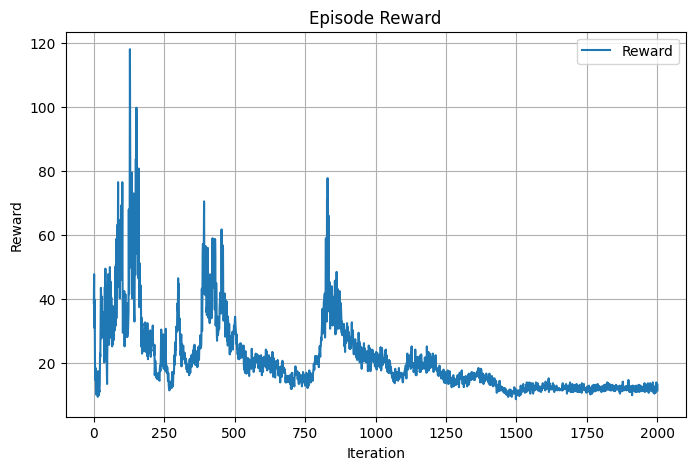

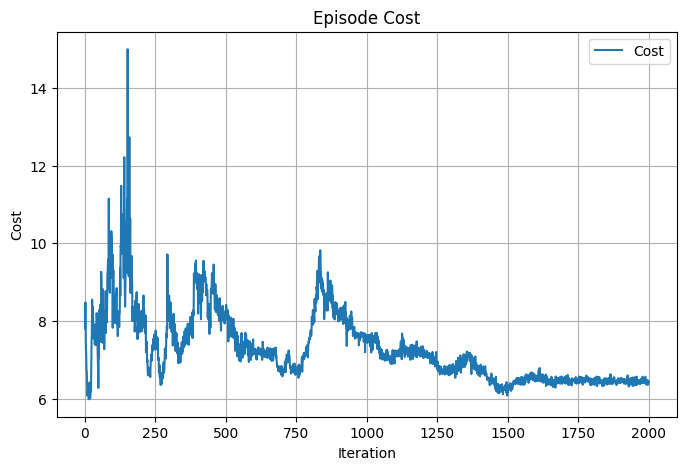

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# load file
df = pd.read_excel("2cartpole_rhcucrl_stable.xlsx")

# check columns
print(df.columns)

# plot raw reward
plt.figure(figsize=(8,5))
plt.plot(df["Iteration"], df["Reward"], label="Reward")
plt.xlabel("Iteration")
plt.ylabel("Reward")
plt.title("Episode Reward")
plt.legend()
plt.grid(True)
plt.show()

# plot raw cost
plt.figure(figsize=(8,5))
plt.plot(df["Iteration"], df["Cost"], label="Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Episode Cost")
plt.legend()
plt.grid(True)
plt.show()

Using device: cuda


Training:   0%|          | 16/3500 [00:00<01:31, 38.10it/s]

Ep   20 | Stage 1 | TrainReward:   29.0 | TrainCost:    0.58 | AvgReward(20):   23.5 | AvgCost(20):    0.97 | EvalNomReward:    9.4 | EvalAdvReward:    9.6 | EvalAdvCost:    0.51


Training:   1%|▏         | 47/3500 [00:01<01:39, 34.58it/s]

Ep   40 | Stage 1 | TrainReward:   12.0 | TrainCost:    0.62 | AvgReward(20):   22.0 | AvgCost(20):    0.85 | EvalNomReward:    9.2 | EvalAdvReward:    9.4 | EvalAdvCost:    0.47


...

Training:  99%|█████████▉| 3480/3500 [4:26:46<01:13,  3.65s/it]

Ep 3480 | Stage 3 | TrainReward:  195.0 | TrainCost:   52.80 | AvgReward(20):  228.4 | AvgCost(20):   64.20 | EvalNomReward:  173.9 | EvalAdvReward:  156.3 | EvalAdvCost:   34.69


Training: 100%|██████████| 3500/3500 [4:27:44<00:00,  4.59s/it]

Ep 3500 | Stage 3 | TrainReward:  196.0 | TrainCost:   52.88 | AvgReward(20):  197.4 | AvgCost(20):   50.72 | EvalNomReward:  200.8 | EvalAdvReward:  170.4 | EvalAdvCost:   37.34
Loaded best checkpoint.



Final Eval without adversary -> Reward: 500.00, Cost: 0.00
Final Eval with adversary    -> Reward: 500.00, Cost: 0.00
Saved: 2cartpole_discrete_staged_results.xlsx


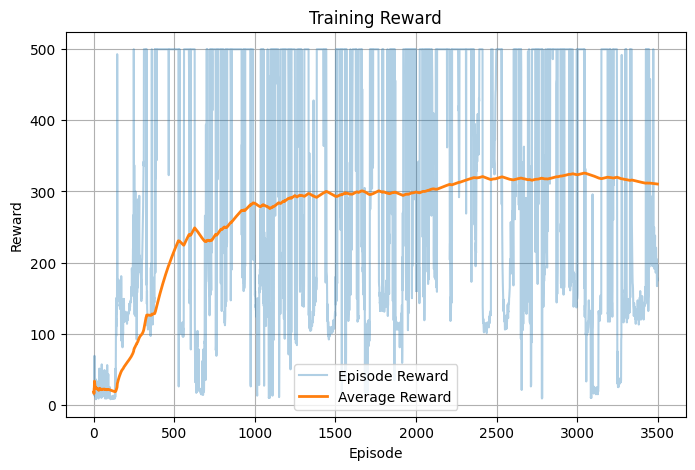

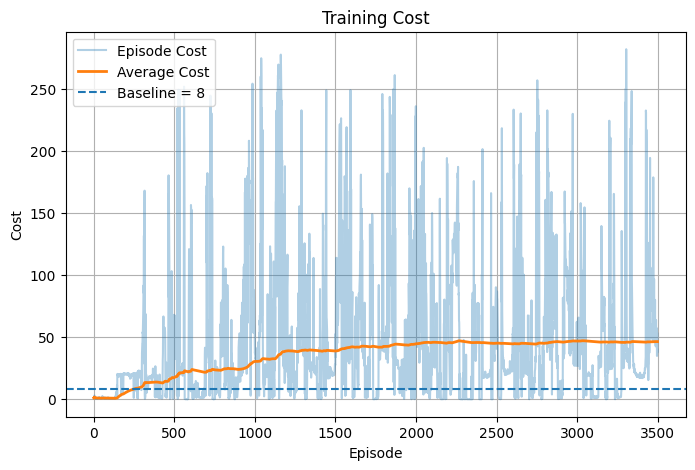

In [16]:
# =========================================
# RHC-UCRL style on CartPole
# Proper discrete-action staged version
# =========================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import gymnasium as gym
from collections import deque
import random
import copy
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================================
# Replay Buffer
# =========================================
class Buffer:
    def __init__(self, size=100000):
        self.buffer = deque(maxlen=size)

    def add(self, s, a_idx, adv, r, c, s_next, done):
        self.buffer.append((s, a_idx, adv, r, c, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a_idx, adv, r, c, s_next, done = zip(*batch)

        return (
            torch.tensor(np.array(s), dtype=torch.float32, device=device),
            torch.tensor(np.array(a_idx), dtype=torch.long, device=device).unsqueeze(1),
            torch.tensor(np.array(adv), dtype=torch.float32, device=device),
            torch.tensor(np.array(r), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(c), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32, device=device),
            torch.tensor(np.array(done), dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


# =========================================
# Networks
# =========================================
class Actor(nn.Module):
    def __init__(self, s_dim, n_actions=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, s):
        return self.net(s)  # logits


class Adversary(nn.Module):
    def __init__(self, s_dim, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, adv_dim),
            nn.Tanh()
        )

    def forward(self, s):
        return self.net(s)


class Critic(nn.Module):
    def __init__(self, s_dim, n_actions, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim + n_actions + adv_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.n_actions = n_actions

    def forward(self, s, a_onehot, adv):
        x = torch.cat([s, a_onehot, adv], dim=-1)
        return self.net(x)


# =========================================
# Utils
# =========================================
def one_hot_actions(a_idx, n_actions=2):
    return F.one_hot(a_idx.squeeze(-1), num_classes=n_actions).float()


def soft_update(net, target_net, tau=0.005):
    for p, tp in zip(net.parameters(), target_net.parameters()):
        tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)


# =========================================
# Adversarial CartPole
# =========================================
class AdversarialCartPole:
    def __init__(self, max_steps=500):
        self.env = gym.make("CartPole-v1")
        self.max_steps = max_steps
        self.step_count = 0
        self.state = None

    def reset(self):
        s, _ = self.env.reset()
        self.state = np.array(s, dtype=np.float32)
        self.step_count = 0
        return self.state

    def step(self, action, adv):
        s_next, _, terminated, truncated, _ = self.env.step(int(action))
        x, x_dot, theta, theta_dot = s_next

        adv = np.array(adv, dtype=np.float32).reshape(-1)
        dv = float(np.clip(adv[0], -1.0, 1.0))
        dtheta_v = float(np.clip(adv[1], -1.0, 1.0))

        # weak adversarial perturbation
        x_dot = x_dot + 0.03 * dv
        theta_dot = theta_dot + 0.03 * dtheta_v

        s_next = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)
        self.state = s_next
        self.step_count += 1

        # standard CartPole reward
        reward = 1.0

        # smooth safety cost
        cost = max(0.0, abs(theta) - 0.05) + 0.5 * max(0.0, abs(x) - 1.0)
        cost = float(cost)

        done = terminated or truncated or (self.step_count >= self.max_steps)
        return s_next, reward, cost, done


# =========================================
# Setup
# =========================================
env = AdversarialCartPole(max_steps=500)
buffer = Buffer(size=100000)

s_dim = 4
n_actions = 2
adv_dim = 2

actor = Actor(s_dim, n_actions).to(device)
adversary = Adversary(s_dim, adv_dim).to(device)

critic_r_o = Critic(s_dim, n_actions, adv_dim).to(device)
critic_r_p = Critic(s_dim, n_actions, adv_dim).to(device)
critic_u_o = Critic(s_dim, n_actions, adv_dim).to(device)
critic_u_p = Critic(s_dim, n_actions, adv_dim).to(device)

critic_r_o_target = copy.deepcopy(critic_r_o)
critic_r_p_target = copy.deepcopy(critic_r_p)
critic_u_o_target = copy.deepcopy(critic_u_o)
critic_u_p_target = copy.deepcopy(critic_u_p)

opt_actor = torch.optim.Adam(actor.parameters(), lr=1e-3)
opt_adv   = torch.optim.Adam(adversary.parameters(), lr=5e-4)

opt_r_o = torch.optim.Adam(critic_r_o.parameters(), lr=1e-3)
opt_r_p = torch.optim.Adam(critic_r_p.parameters(), lr=1e-3)
opt_u_o = torch.optim.Adam(critic_u_o.parameters(), lr=1e-3)
opt_u_p = torch.optim.Adam(critic_u_p.parameters(), lr=1e-3)

gamma = 0.99
tau = 0.005
num_episodes = 3500
batch_size = 256
start_train_after = 2000

# stages
stage1_end = 600   # learn plain CartPole
stage2_end = 700   # learn with weak adversary
# stage3 = remaining episodes -> add safety penalty

reward_hist = []
cost_hist = []
eval_reward_hist = []
eval_cost_hist = []

best_score = -1e9
best_actor_state = None
best_adv_state = None


# =========================================
# Action helpers
# =========================================
def sample_actor_action(s_np, greedy=False):
    s_t = torch.tensor(s_np, dtype=torch.float32, device=device)
    logits = actor(s_t)

    if greedy:
        action = torch.argmax(logits).item()
        logp = None
    else:
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample().item()
        logp = dist.log_prob(torch.tensor(action, device=device))

    return action, logp


def evaluate_policy(env, actor, adversary, episodes=10, use_adversary=True):
    actor.eval()
    adversary.eval()

    rewards = []
    costs = []

    with torch.no_grad():
        for _ in range(episodes):
            s = env.reset()
            total_r = 0.0
            total_c = 0.0

            for _ in range(env.max_steps):
                s_t = torch.tensor(s, dtype=torch.float32, device=device)
                logits = actor(s_t)
                action = torch.argmax(logits).item()

                if use_adversary:
                    adv = adversary(s_t).cpu().numpy()
                else:
                    adv = np.zeros((adv_dim,), dtype=np.float32)

                s_next, r, c, done = env.step(action, adv)

                total_r += r
                total_c += c
                s = s_next

                if done:
                    break

            rewards.append(total_r)
            costs.append(total_c)

    actor.train()
    adversary.train()

    return float(np.mean(rewards)), float(np.mean(costs))


# =========================================
# Training
# =========================================
for ep in tqdm(range(num_episodes), desc="Training"):
    s = env.reset()
    total_r = 0.0
    total_c = 0.0

    # stage logic
    if ep < stage1_end:
        stage = 1
        lambda_penalty = 0.0
        adv_scale = 0.0
        adv_train = False
    elif ep < stage2_end:
        stage = 2
        lambda_penalty = 0.0
        adv_scale = 0.3
        adv_train = True
    else:
        stage = 3
        lambda_penalty = 1.0
        adv_scale = 0.05
        adv_train = True

    for t in range(env.max_steps):
        # sample discrete action
        action, _ = sample_actor_action(s, greedy=False)

        # adversary
        s_t = torch.tensor(s, dtype=torch.float32, device=device)
        with torch.no_grad():
            adv = adversary(s_t).cpu().numpy()
            adv = adv_scale * adv

        s_next, r, c, done = env.step(action, adv)

        buffer.add(s, action, adv, r, c, s_next, done)
        s = s_next
        total_r += r
        total_c += c

        if len(buffer) > start_train_after:
            S, A_idx, ADV, R, C, S_next, D = buffer.sample(batch_size)
            A_onehot = one_hot_actions(A_idx, n_actions=n_actions)

            with torch.no_grad():
                not_done = 1.0 - D

                # next actor distribution
                next_logits = actor(S_next)
                next_probs = torch.softmax(next_logits, dim=-1)

                # current adv at next state
                ADV_next = adv_scale * adversary(S_next)

                # expected next Q under current policy
                q_ro_list, q_rp_list, q_uo_list, q_up_list = [], [], [], []

                for a_i in range(n_actions):
                    a_next_idx = torch.full((S_next.shape[0], 1), a_i, dtype=torch.long, device=device)
                    a_next_oh = one_hot_actions(a_next_idx, n_actions=n_actions)

                    q_ro_list.append(critic_r_o_target(S_next, a_next_oh, ADV_next))
                    q_rp_list.append(critic_r_p_target(S_next, a_next_oh, ADV_next))
                    q_uo_list.append(critic_u_o_target(S_next, a_next_oh, ADV_next))
                    q_up_list.append(critic_u_p_target(S_next, a_next_oh, ADV_next))

                q_ro_all = torch.cat(q_ro_list, dim=1)
                q_rp_all = torch.cat(q_rp_list, dim=1)
                q_uo_all = torch.cat(q_uo_list, dim=1)
                q_up_all = torch.cat(q_up_list, dim=1)

                exp_q_ro = (next_probs * q_ro_all).sum(dim=1, keepdim=True)
                exp_q_rp = (next_probs * q_rp_all).sum(dim=1, keepdim=True)
                exp_q_uo = (next_probs * q_uo_all).sum(dim=1, keepdim=True)
                exp_q_up = (next_probs * q_up_all).sum(dim=1, keepdim=True)

                target_r_o = R + gamma * not_done * exp_q_ro
                target_r_p = R + gamma * not_done * exp_q_rp
                target_u_o = C + gamma * not_done * exp_q_uo
                target_u_p = C + gamma * not_done * exp_q_up

            # critics
            loss_ro = ((critic_r_o(S, A_onehot, ADV) - target_r_o) ** 2).mean()
            opt_r_o.zero_grad()
            loss_ro.backward()
            torch.nn.utils.clip_grad_norm_(critic_r_o.parameters(), 1.0)
            opt_r_o.step()

            loss_rp = ((critic_r_p(S, A_onehot, ADV) - target_r_p) ** 2).mean()
            opt_r_p.zero_grad()
            loss_rp.backward()
            torch.nn.utils.clip_grad_norm_(critic_r_p.parameters(), 1.0)
            opt_r_p.step()

            loss_uo = ((critic_u_o(S, A_onehot, ADV) - target_u_o) ** 2).mean()
            opt_u_o.zero_grad()
            loss_uo.backward()
            torch.nn.utils.clip_grad_norm_(critic_u_o.parameters(), 1.0)
            opt_u_o.step()

            loss_up = ((critic_u_p(S, A_onehot, ADV) - target_u_p) ** 2).mean()
            opt_u_p.zero_grad()
            loss_up.backward()
            torch.nn.utils.clip_grad_norm_(critic_u_p.parameters(), 1.0)
            opt_u_p.step()

            soft_update(critic_r_o, critic_r_o_target, tau)
            soft_update(critic_r_p, critic_r_p_target, tau)
            soft_update(critic_u_o, critic_u_o_target, tau)
            soft_update(critic_u_p, critic_u_p_target, tau)

            # =========================================
            # Actor update: expected policy objective
            # =========================================
            logits = actor(S)
            probs = torch.softmax(logits, dim=-1)

            ADV_fixed = adv_scale * adversary(S).detach()

            q_r_vals = []
            q_u_vals = []
            for a_i in range(n_actions):
                a_i_idx = torch.full((S.shape[0], 1), a_i, dtype=torch.long, device=device)
                a_i_oh = one_hot_actions(a_i_idx, n_actions=n_actions)
                q_r_vals.append(critic_r_o(S, a_i_oh, ADV_fixed))
                q_u_vals.append(critic_u_o(S, a_i_oh, ADV_fixed))

            q_r_all = torch.cat(q_r_vals, dim=1)
            q_u_all = torch.cat(q_u_vals, dim=1)

            exp_q_r = (probs * q_r_all).sum(dim=1, keepdim=True)
            exp_q_u = (probs * q_u_all).sum(dim=1, keepdim=True)

            # stage-wise actor objective
            if stage < 3:
                actor_loss = -exp_q_r.mean()
            else:
                b = 30.0
                actor_loss = -(exp_q_r - lambda_penalty * torch.relu(exp_q_u - b)).mean()

            entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1).mean()
            actor_loss = actor_loss - 0.01 * entropy

            opt_actor.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
            opt_actor.step()

            # =========================================
            # Adversary update
            # =========================================
            if adv_train and (t % 20 == 0):
                ADV_pred = adv_scale * adversary(S)
                logits_fixed = actor(S).detach()
                probs_fixed = torch.softmax(logits_fixed, dim=-1)

                q_r_adv_vals = []
                q_u_adv_vals = []

                for a_i in range(n_actions):
                    a_i_idx = torch.full((S.shape[0], 1), a_i, dtype=torch.long, device=device)
                    a_i_oh = one_hot_actions(a_i_idx, n_actions=n_actions)
                    q_r_adv_vals.append(critic_r_p(S, a_i_oh, ADV_pred))
                    q_u_adv_vals.append(critic_u_p(S, a_i_oh, ADV_pred))

                q_r_adv_all = torch.cat(q_r_adv_vals, dim=1)
                q_u_adv_all = torch.cat(q_u_adv_vals, dim=1)

                exp_q_r_adv = (probs_fixed * q_r_adv_all).sum(dim=1, keepdim=True)
                exp_q_u_adv = (probs_fixed * q_u_adv_all).sum(dim=1, keepdim=True)

                if stage < 3:
                    adv_loss = exp_q_r_adv.mean()
                else:
                    b = 30.0
                    adv_loss = (exp_q_r_adv - lambda_penalty * torch.relu(exp_q_u_adv - b)).mean()

                opt_adv.zero_grad()
                adv_loss.backward()
                torch.nn.utils.clip_grad_norm_(adversary.parameters(), 1.0)
                opt_adv.step()

        if done:
            break

    reward_hist.append(total_r)
    cost_hist.append(total_c)

    if (ep + 1) % 20 == 0:
        eval_r_nominal, eval_c_nominal = evaluate_policy(env, actor, adversary, episodes=10, use_adversary=False)
        eval_r_adv, eval_c_adv = evaluate_policy(env, actor, adversary, episodes=10, use_adversary=True)

        eval_reward_hist.append(eval_r_adv)
        eval_cost_hist.append(eval_c_adv)

        print(
            f"Ep {ep+1:4d} | Stage {stage} | "
            f"TrainReward: {total_r:6.1f} | TrainCost: {total_c:7.2f} | "
            f"AvgReward(20): {np.mean(reward_hist[-20:]):6.1f} | AvgCost(20): {np.mean(cost_hist[-20:]):7.2f} | "
            f"EvalNomReward: {eval_r_nominal:6.1f} | EvalAdvReward: {eval_r_adv:6.1f} | EvalAdvCost: {eval_c_adv:7.2f}"
        )

        score = eval_r_adv - 2.0 * eval_c_adv
        if score > best_score:
            best_score = score
            best_actor_state = copy.deepcopy(actor.state_dict())
            best_adv_state = copy.deepcopy(adversary.state_dict())


# =========================================
# Load best checkpoint
# =========================================
if best_actor_state is not None:
    actor.load_state_dict(best_actor_state)
    adversary.load_state_dict(best_adv_state)
    print("Loaded best checkpoint.")


# =========================================
# Final eval
# =========================================
final_nom_r, final_nom_c = evaluate_policy(env, actor, adversary, episodes=20, use_adversary=False)
final_adv_r, final_adv_c = evaluate_policy(env, actor, adversary, episodes=20, use_adversary=True)

print(f"\nFinal Eval without adversary -> Reward: {final_nom_r:.2f}, Cost: {final_nom_c:.2f}")
print(f"Final Eval with adversary    -> Reward: {final_adv_r:.2f}, Cost: {final_adv_c:.2f}")


# =========================================
# Save results
# =========================================
df = pd.DataFrame({
    "Episode": np.arange(1, len(reward_hist) + 1),
    "Reward": reward_hist,
    "Cost": cost_hist,
    "Average Reward": np.cumsum(reward_hist) / np.arange(1, len(reward_hist) + 1),
    "Average Cost": np.cumsum(cost_hist) / np.arange(1, len(cost_hist) + 1),
})
df.to_excel("2cartpole_discrete_staged_results.xlsx", index=False)
print("Saved: 2cartpole_discrete_staged_results.xlsx")


# =========================================
# Plot
# =========================================
avg_reward = np.cumsum(reward_hist) / np.arange(1, len(reward_hist) + 1)
avg_cost = np.cumsum(cost_hist) / np.arange(1, len(cost_hist) + 1)

plt.figure(figsize=(8,5))
plt.plot(reward_hist, alpha=0.35, label="Episode Reward")
plt.plot(avg_reward, linewidth=2, label="Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(cost_hist, alpha=0.35, label="Episode Cost")
plt.plot(avg_cost, linewidth=2, label="Average Cost")
plt.axhline(y=8, linestyle="--", label="Baseline = 8")
plt.xlabel("Episode")
plt.ylabel("Cost")
plt.title("Training Cost")
plt.legend()
plt.grid(True)
plt.show()

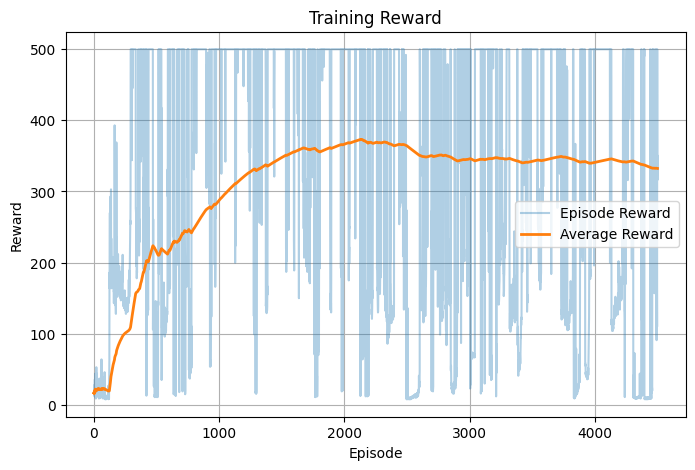

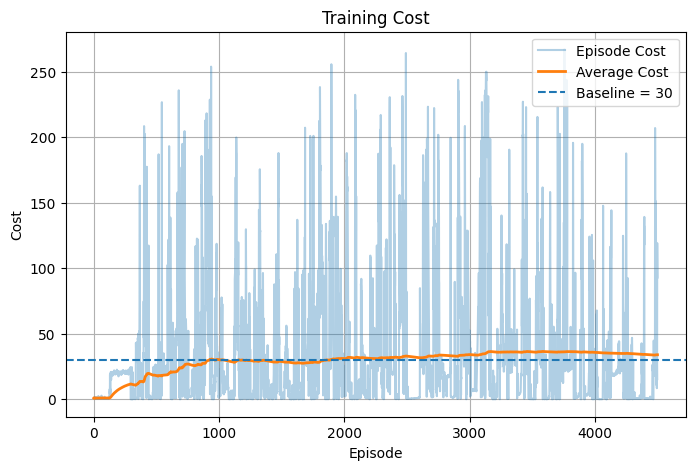

In [15]:
avg_reward = np.cumsum(reward_hist) / np.arange(1, len(reward_hist) + 1)
avg_cost = np.cumsum(cost_hist) / np.arange(1, len(cost_hist) + 1)

plt.figure(figsize=(8,5))
plt.plot(reward_hist, alpha=0.35, label="Episode Reward")
plt.plot(avg_reward, linewidth=2, label="Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(cost_hist, alpha=0.35, label="Episode Cost")
plt.plot(avg_cost, linewidth=2, label="Average Cost")
plt.axhline(y=30, linestyle="--", label="Baseline = 30")
plt.xlabel("Episode")
plt.ylabel("Cost")
plt.title("Training Cost")
plt.legend()
plt.grid(True)
plt.show()